In [1]:
#                             ============================================================

#                                Flight Fare Prediction Capestone Project

#                             ============================================================

In [2]:
# ============================================================
# 0. IMPORTS & SETUP
# ============================================================

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (10,5), 'axes.titlesize': 14})


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


print(' All libraries imported succesfully!')


 All libraries imported succesfully!


In [4]:
# ============================================================
# 1. Load & Preview Dataset
# ============================================================

In [5]:
df = pd.read_excel('Flight_Fare.xlsx')
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [6]:
print(f' Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')

 Dataset Shape: 10683 rows x 11 columns


In [7]:
df.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [8]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [9]:
print('\nColumn Data Types:')
print(df.dtypes)


Column Data Types:
Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object


In [10]:
print('\nBasic Info:')
df.info()


Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [11]:
# ============================================================
# 2. MISSING VALUES
# ============================================================

In [12]:
missing = df.isnull().sum()
missing

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [13]:
missing_pct = (missing / len(df) * 100).round(2)
missing_pct

Airline            0.00
Date_of_Journey    0.00
Source             0.00
Destination        0.00
Route              0.01
Dep_Time           0.00
Arrival_Time       0.00
Duration           0.00
Total_Stops        0.01
Additional_Info    0.00
Price              0.00
dtype: float64

In [14]:
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df

,Missing Count,Missing %
Airline,0,0.00
Date_of_Journey,0,0.00
Source,0,0.00
Destination,0,0.00
Route,1,0.01
Dep_Time,0,0.00
Arrival_Time,0,0.00
Duration,0,0.00
Total_Stops,1,0.01
Additional_Info,0,0.00


In [15]:
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df

,Missing Count,Missing %
Route,1,0.01
Total_Stops,1,0.01


In [16]:
print('\nMissing values Summary:')

print(missing_df if not missing_df.empty else 'No  Missing values found!')


Missing values Summary:
             Missing Count  Missing %
Route                    1       0.01
Total_Stops              1       0.01


In [17]:
# VISUALIZE

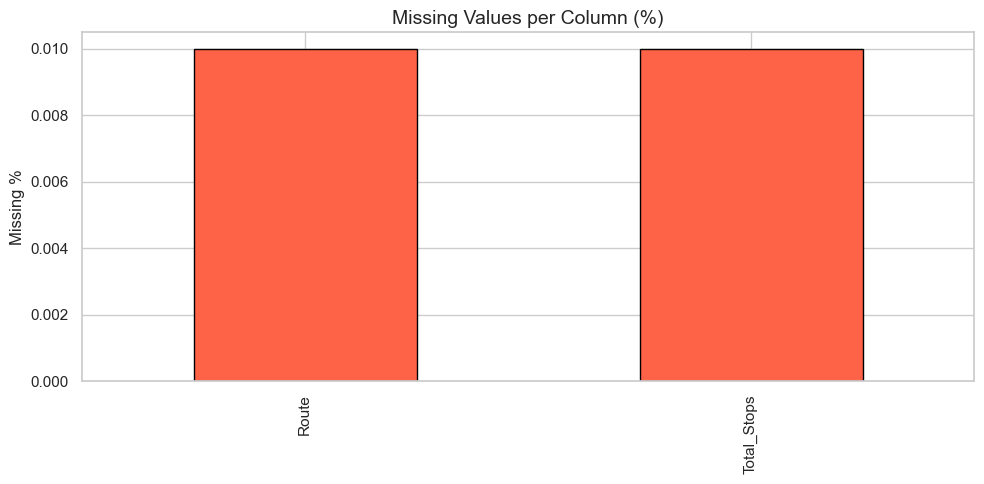

In [18]:
if not missing_df.empty:
    missing_df['Missing %'].plot(kind='bar', color='tomato', edgecolor='black')
    plt.title('Missing Values per Column (%)')
    plt.ylabel('Missing %')
    plt.tight_layout()
    plt.show()

In [19]:
# ============================================================
# 3. Price Distribution (Target Variable)
# ============================================================

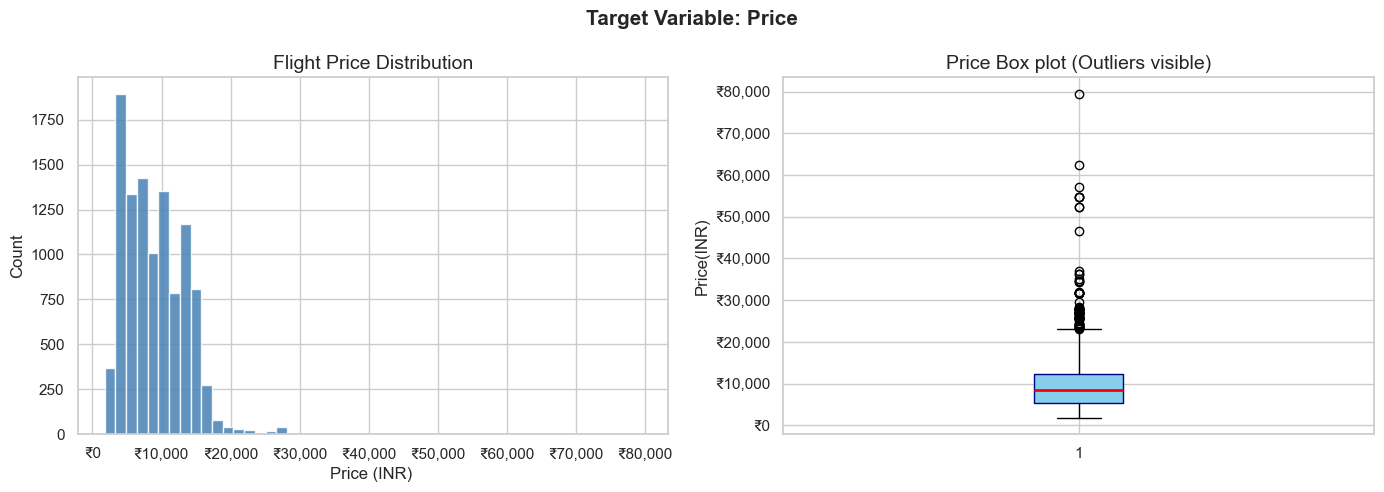

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram

axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Flight Price Distribution')
axes[0].set_xlabel('Price (INR) ')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))

# Box plot

axes[1].boxplot(df['Price'], patch_artist=True,
                boxprops=dict(facecolor='skyblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))

axes[1].set_title('Price Box plot (Outliers visible)')
axes[1].set_ylabel('Price(INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))

plt.suptitle('Target Variable: Price', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



In [21]:
# ============================================================
# 4. Airline -  Wise Analysis
# ============================================================

In [22]:
airline_counts = df['Airline'].value_counts()
airline_counts

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [23]:
airline_avg_price = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)
airline_avg_price

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11643.923357
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9611.210616
Vistara Premium economy               8962.333333
Vistara                               7796.348643
GoAir                                 5861.056701
IndiGo                                5673.682903
Air Asia                              5590.260188
SpiceJet                              4338.284841
Trujet                                4140.000000
Name: Price, dtype: float64

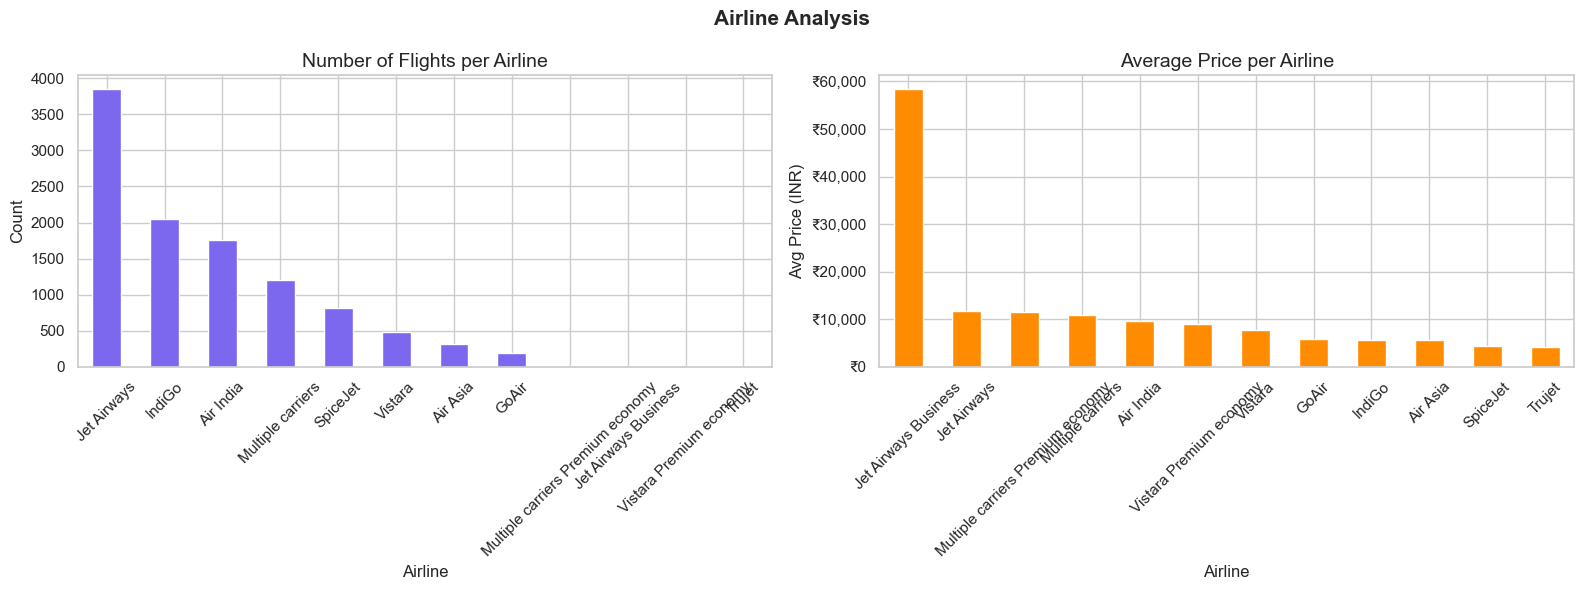

In [24]:
fig,axes = plt.subplots(1,2, figsize=(16,6))

# Count
airline_counts.plot(kind='bar', ax=axes[0], color='mediumslateblue', edgecolor='white')
axes[0].set_title('Number of Flights per Airline')
axes[0].set_xlabel('Airline')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)


# Avg price

airline_avg_price.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Average Price per Airline')
axes[1].set_xlabel('Airline')
axes[1].set_ylabel('Avg Price (INR)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))

plt.suptitle('Airline Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



In [25]:
# ============================================================
# 5. Source & Destination  Analysis
# ============================================================

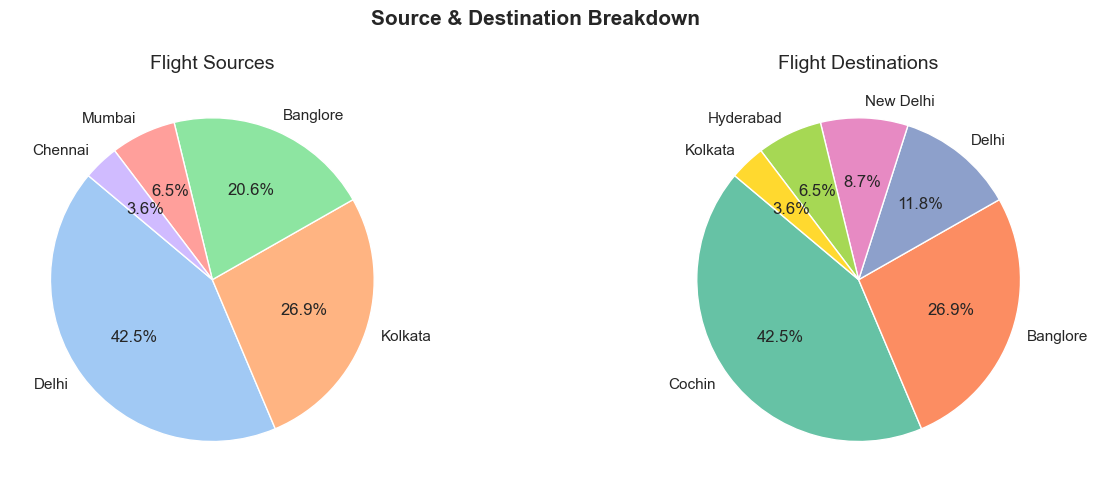

In [26]:
fig, axes = plt.subplots(1,2, figsize=(14, 5))

df['Source'].value_counts().plot(kind='pie',
                                 ax=axes[0],
                                 autopct='%1.1f%%',
                                 startangle=140,
                                 colors=sns.color_palette('pastel'))
axes[0].set_title('Flight Sources')
axes[0].set_ylabel('')


df['Destination'].value_counts().plot(kind='pie',
                                      ax=axes[1],
                                      autopct='%1.1f%%',
                                      startangle=140,
                                      colors=sns.color_palette('Set2'))
axes[1].set_title('Flight Destinations')
axes[1].set_ylabel('')

plt.suptitle('Source & Destination Breakdown', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
                                      
                                      



In [27]:
# ============================================================
# 6. Total Stops Vs Price
# ============================================================

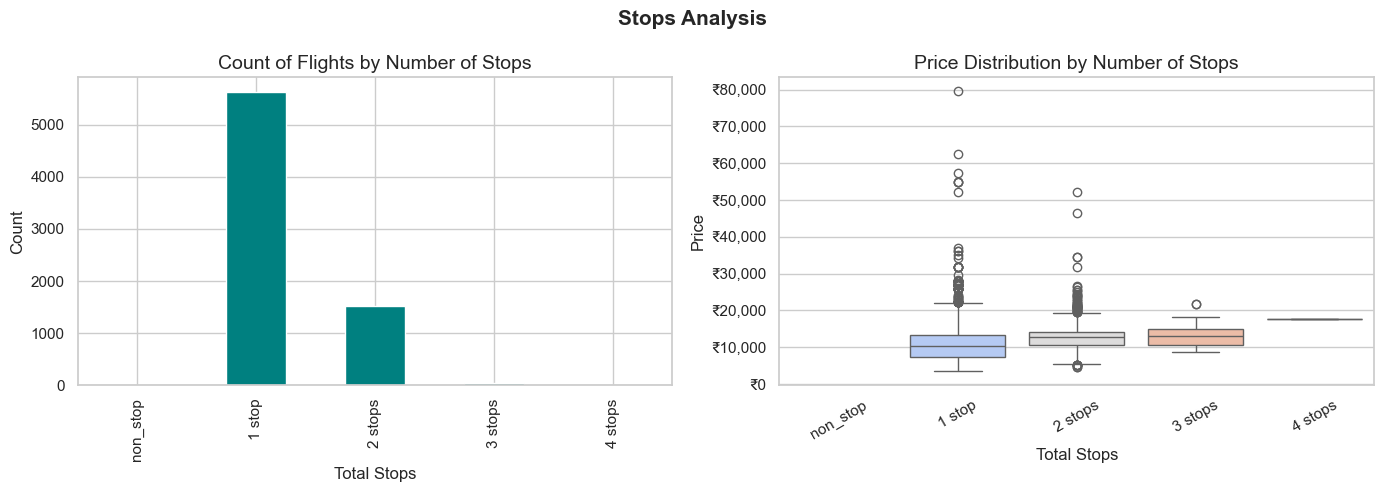

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

stop_order = ['non_stop', '1 stop', '2 stops', '3 stops', '4 stops']
stop_counts = df['Total_Stops'].value_counts()


stop_counts.reindex(stop_order, fill_value=0).plot(kind='bar',
                                                   ax=axes[0],
                                                   color='teal',
                                                   edgecolor='white')

axes[0].set_title('Count of Flights by Number of Stops')
axes[0].set_xlabel('Total Stops')
axes[0].set_ylabel('Count')


sns.boxplot(data=df,
            x='Total_Stops',
            order=stop_order,
            y='Price',
            ax=axes[1],
            palette='coolwarm')

axes[1].set_title('Price Distribution by Number of Stops')
axes[1].set_xlabel('Total Stops')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))


plt.suptitle('Stops Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

            
                                                   




In [29]:
# ============================================================
# 7. Airline  Vs Price (Box Plot)
# ============================================================

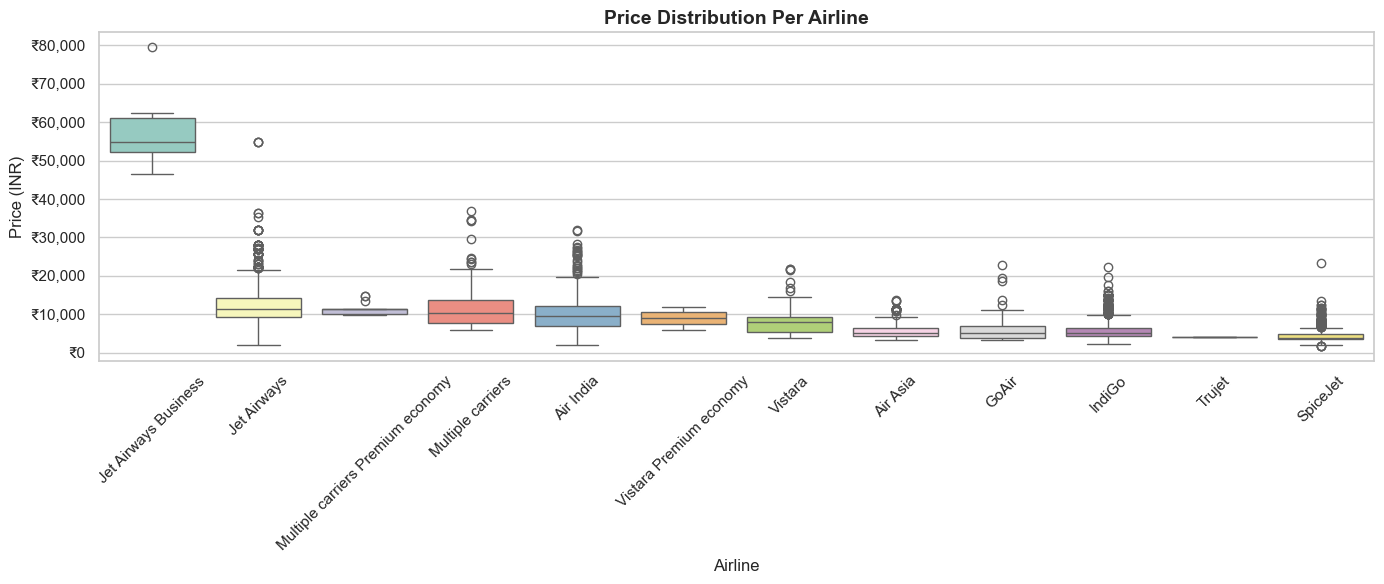

In [30]:
plt.figure(figsize=(14, 6))
order = df.groupby('Airline')['Price'].median().sort_values(ascending=False).index


sns.boxplot(data=df, x='Airline', y='Price', order=order, palette='Set3')
plt.title('Price Distribution Per Airline', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Price (INR)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# 8. Departure Hour Analysis
# ============================================================

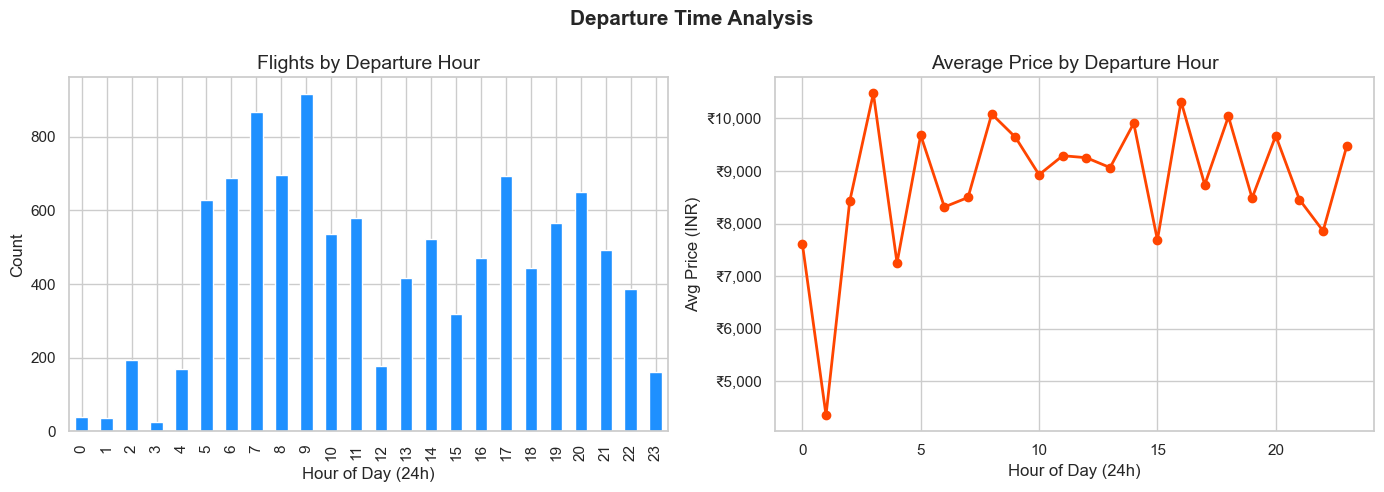

In [32]:
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time'], format='%H:%M', errors='coerce').dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14,5))

df['Dep_Hour'].value_counts().sort_index().plot(kind='bar',
                                                 ax=axes[0],
                                                 color='dodgerblue',
                                                 edgecolor='white')
                                                
axes[0].set_title('Flights by Departure Hour')
axes[0].set_xlabel('Hour of Day (24h)')
axes[0].set_ylabel('Count')


df.groupby('Dep_Hour')['Price'].mean().plot(ax=axes[1],
                                            marker='o',
                                            color='orangered',
                                            linewidth=2)
axes[1].set_title('Average Price by Departure Hour')
axes[1].set_xlabel('Hour of Day (24h)')
axes[1].set_ylabel('Avg Price (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))

plt.suptitle('Departure Time Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# 9.Feature Engineering & Data Preprocessing
# ============================================================

In [34]:
data = df.copy()
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Dep_Hour
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,22
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,18
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,16
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,19
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,20
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,8
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,11


In [35]:
# 9.1. Drop missing rows (only 1-2 rows)

In [36]:
data.dropna(inplace=True)
print(f'Rows After dropping nulls: {len(data)}')

Rows After dropping nulls: 10682


In [37]:
# 9.2. Parse Date_of_Journey 

In [38]:

data['Journey_Day']   = pd.to_datetime(data['Date_of_Journey'], dayfirst=True).dt.day
data['Journey_Month'] = pd.to_datetime(data['Date_of_Journey'], dayfirst=True).dt.month
data.drop('Date_of_Journey', axis=1, inplace=True)



In [39]:
# 9.3. Parse Dep_Time

In [40]:
data['Dep_Hour'] = pd.to_datetime(data['Dep_Time'], format='%H:%M', errors='coerce').dt.hour
data['Dep_Minute'] = pd.to_datetime(data['Dep_Time'], format="%H:%M", errors='coerce').dt.minute
data.drop('Dep_Time', axis=1, inplace=True)


In [41]:
# 9.4. Parse Arrival Time

In [42]:
data['Arr_Hour'] = pd.to_datetime(data['Arrival_Time'].str.split(' ').str[0], format='%H:%M', errors='coerce').dt.hour
data['Arr_Minute'] = pd.to_datetime(data['Arrival_Time'].str.split(' ').str[0], format='%H:%M',errors='coerce').dt.minute
data.drop('Arrival_Time', axis=1, inplace=True)

In [43]:
#9.5. Parse Duration → total minutes

In [44]:
def parse_duration(dur):
    try:
        parts= str(dur).strip().split()
        total = 0
        for p in parts:
            if 'h' in p: total += int(p.replace('h','')) * 60
            elif 'm' in p: total += int(p.replace('m', ''))
        return total
    except:
        return np.nan


data['Duration_mins'] = data['Duration'].apply(parse_duration)
data.drop('Duration', axis=1, inplace=True)



        
        
            

In [45]:
#  9.6. Encode Total_Stops

In [46]:
stops_map = {'non-stop':0, '1 stop':1, '2 stops': 2, '3 stops': 3, '4 stops': 4 }
data['Total_Stops'] = data['Total_Stops'].map(stops_map)

In [47]:
# 9.7. Drop Route (redundant) & Additional_Info (high cardinality) 

In [48]:
data.drop(['Route', 'Additional_Info'], axis=1, inplace=True)

In [49]:
# 9.8. One-Hot Encode categorical columns

In [50]:
data = pd.get_dummies(data, columns=['Airline', 'Source', 'Destination'], drop_first=True)


In [51]:
print(f' Final dataset Shape: {data.shape}')
data.head(6)


 Final dataset Shape: (10682, 29)


,Total_Stops,Price,Dep_Hour,Journey_Day,Journey_Month,Dep_Minute,Arr_Hour,Arr_Minute,Duration_mins,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,22,24,3,20,1,10,170,False,...,False,False,False,False,False,False,False,False,False,True
1,2,7662,5,1,5,50,13,15,445,True,...,False,False,False,True,False,False,False,False,False,False
2,2,13882,9,9,6,25,4,25,1140,False,...,False,False,True,False,False,True,False,False,False,False
3,1,6218,18,12,5,5,23,30,325,False,...,False,False,False,True,False,False,False,False,False,False
4,1,13302,16,1,3,50,21,35,285,False,...,False,False,False,False,False,False,False,False,False,True
5,0,3873,9,24,6,0,11,25,145,False,...,False,False,False,True,False,False,False,False,False,False


In [52]:
# ============================================================
# 10.Correlation Heatmap (Numerical Features)              
# ============================================================

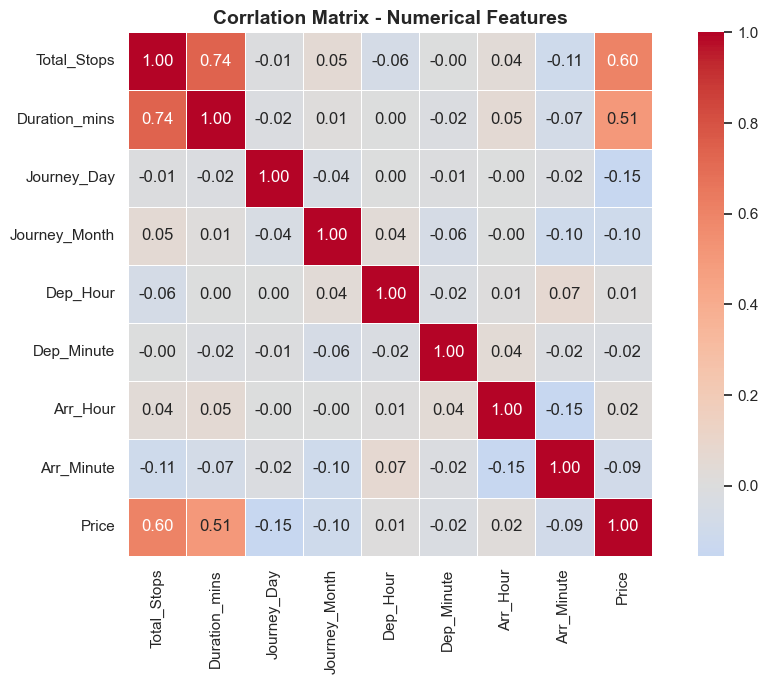

In [53]:
num_cols = ['Total_Stops', 'Duration_mins', 'Journey_Day', 'Journey_Month',
            'Dep_Hour', 'Dep_Minute', 'Arr_Hour', 'Arr_Minute', 'Price']

plt.figure(figsize=(10,7))
sns.heatmap(data[num_cols].corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidth=0.5
           )

plt.title('Corrlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# 11.Train / Test Split             
# ============================================================

In [55]:
X = data.drop('Price', axis=1)
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f' Training Set  : {X_train.shape}')
print(f' Test Set      : {X_test.shape}')

 Training Set  : (8545, 28)
 Test Set      : (2137, 28)


In [56]:
# ============================================================
# 12. Model Training & Evaluation          
# ============================================================

In [57]:
def evaluate(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    cv    = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    return {'Model': name,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'R² (Test)' : round(r2, 4),
            'R² (CV 5-fold)': round(cv,4),
            '_model': model,
            '_preds': preds }

models_to_run = [
    ('Linear Regression',           LinearRegression()),
    ('Ridge Regression',            Ridge(alpha=1.0)),
    ('Lasso Regression',            Lasso(alpha=1.0)),
    ('Decision Tree',               DecisionTreeRegressor(max_depth=10, random_state=42)),
    ('Random Forest',               RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('Gradient Boosting',           GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('XGBoost',                     XGBRegressor(n_estimators=100, reandom_state=42, verbosity=0)),
]

results = []
print('Training models...')

for name, m in models_to_run:
    r = evaluate(name, m, X_train, y_train, X_test, y_test)
    results.append(r)
    print(f" {name:30s}  | R²={r['R² (Test)']:.4f} | MAE=₹{r['MAE']:,.0f}")


print('\n All models trained! ')
    
 
            
    

Training models...
 Linear Regression               | R²=0.6197 | MAE=₹1,973
 Ridge Regression                | R²=0.6187 | MAE=₹1,977
 Lasso Regression                | R²=0.6192 | MAE=₹1,974
 Decision Tree                   | R²=0.8199 | MAE=₹1,337
 Random Forest                   | R²=0.8214 | MAE=₹1,162
 Gradient Boosting               | R²=0.7890 | MAE=₹1,518
 XGBoost                         | R²=0.8418 | MAE=₹1,144

 All models trained! 


In [59]:

def evaluate_model(name, model):
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='r2'
    ).mean()

    print(f"Model: {name}")
    print(f"MAE  : ₹{mae:,.2f}")
    print(f"RMSE : ₹{rmse:,.2f}")
    print(f"Test R² : {r2:.4f}")
    print(f"CV R² (5-fold): {cv:.4f}")
    print("-"*40)

    return model, preds




lr_model = LinearRegression()

lr_model, lr_preds = evaluate_model(
    "Linear Regression",
    lr_model
) 



ridge_model = Ridge(alpha=1.0)

ridge_model, ridge_preds = evaluate_model(
    "Ridge Regression",
    ridge_model
)



lasso_model = Lasso(alpha=1.0)

lasso_model, lasso_preds = evaluate_model(
    "Lasso Regression",
    lasso_model
)

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model, dt_preds = evaluate_model(
    "Decision Tree",
    dt_model
)



rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model, rf_preds = evaluate_model(
    "Random Forest",
    rf_model
)


gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_model, gb_preds = evaluate_model(
    "Gradient Boosting",
    gb_model
)


xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    verbosity=0
)

xgb_model, xgb_preds = evaluate_model(
    "XGBoost",
    xgb_model
)

Model: Linear Regression
MAE  : ₹1,972.95
RMSE : ₹2,863.63
Test R² : 0.6197
CV R² (5-fold): 0.6188
----------------------------------------
Model: Ridge Regression
MAE  : ₹1,977.13
RMSE : ₹2,867.50
Test R² : 0.6187
CV R² (5-fold): 0.6175
----------------------------------------
Model: Lasso Regression
MAE  : ₹1,973.99
RMSE : ₹2,865.62
Test R² : 0.6192
CV R² (5-fold): 0.6190
----------------------------------------
Model: Decision Tree
MAE  : ₹1,336.79
RMSE : ₹1,970.72
Test R² : 0.8199
CV R² (5-fold): 0.7431
----------------------------------------
Model: Random Forest
MAE  : ₹1,161.52
RMSE : ₹1,962.42
Test R² : 0.8214
CV R² (5-fold): 0.7987
----------------------------------------
Model: Gradient Boosting
MAE  : ₹1,518.40
RMSE : ₹2,133.01
Test R² : 0.7890
CV R² (5-fold): 0.7611
----------------------------------------
Model: XGBoost
MAE  : ₹1,144.06
RMSE : ₹1,846.98
Test R² : 0.8418
CV R² (5-fold): 0.8219
----------------------------------------


In [ ]:
# ============================================================
# 13. Model Comparison Report        
# ============================================================

In [60]:
report_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
report_df

,Model,MAE,RMSE,R² (Test),R² (CV 5-fold)
0,Linear Regression,1972.95,2863.63,0.6197,0.6188
1,Ridge Regression,1977.13,2867.50,0.6187,0.6175
2,Lasso Regression,1973.99,2865.62,0.6192,0.6190
3,Decision Tree,1336.79,1970.72,0.8199,0.7431
4,Random Forest,1161.52,1962.42,0.8214,0.7987
5,Gradient Boosting,1518.40,2133.01,0.7890,0.7611
6,XGBoost,1144.06,1846.98,0.8418,0.8219


In [62]:
report_df =report_df. sort_values('R² (Test)', ascending=False).reset_index(drop=True)
report_df

,Model,MAE,RMSE,R² (Test),R² (CV 5-fold)
0,XGBoost,1144.06,1846.98,0.8418,0.8219
1,Random Forest,1161.52,1962.42,0.8214,0.7987
2,Decision Tree,1336.79,1970.72,0.8199,0.7431
3,Gradient Boosting,1518.40,2133.01,0.7890,0.7611
4,Linear Regression,1972.95,2863.63,0.6197,0.6188
5,Lasso Regression,1973.99,2865.62,0.6192,0.6190
6,Ridge Regression,1977.13,2867.50,0.6187,0.6175


In [64]:
report_df.index += 1
print('Model Performance Summary( sorted by R² Test Score):')
report_df

Model Performance Summary( sorted by R² Test Score):


,Model,MAE,RMSE,R² (Test),R² (CV 5-fold)
2,XGBoost,1144.06,1846.98,0.8418,0.8219
3,Random Forest,1161.52,1962.42,0.8214,0.7987
4,Decision Tree,1336.79,1970.72,0.8199,0.7431
5,Gradient Boosting,1518.40,2133.01,0.7890,0.7611
6,Linear Regression,1972.95,2863.63,0.6197,0.6188
7,Lasso Regression,1973.99,2865.62,0.6192,0.6190
8,Ridge Regression,1977.13,2867.50,0.6187,0.6175


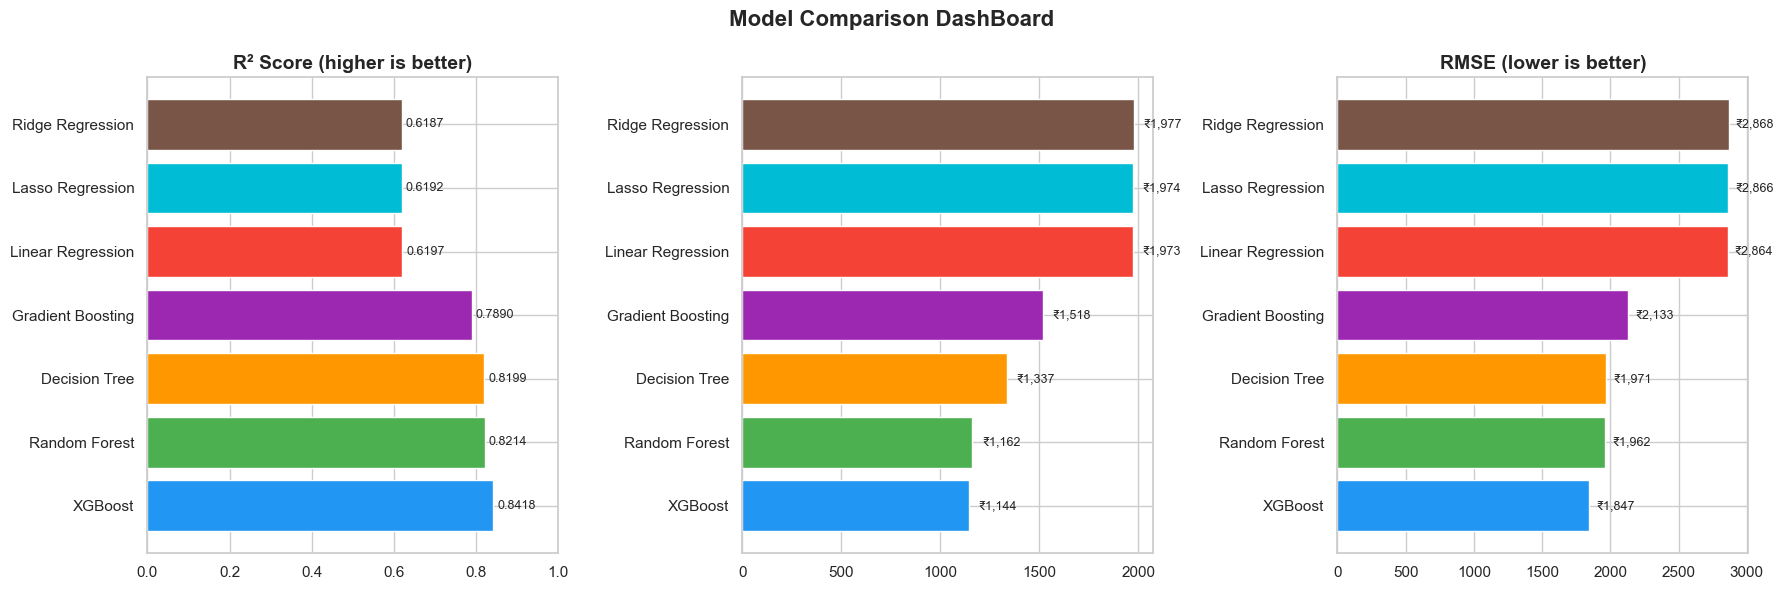

In [67]:
fig,axes = plt.subplots(1, 3, figsize=(18,6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4', '#795548']

names = report_df['Model'].tolist()

# R²

bars = axes[0].barh(names, report_df['R² (Test)'], color=colors, edgecolor='white')
axes[0].set_title('R² Score (higher is better)', fontweight='bold')
axes[0].set_xlim(0, 1)
for bar, v in zip(bars, report_df['R² (Test)']):
    axes[0].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)

# MAE

bars2 = axes[1].barh(names, report_df['MAE'], color=colors, edgecolor='white')
axes[2].set_title('MAE (lower is better)', fontweight='bold')
for bar, v in zip(bars2, report_df['MAE']):
    axes[1].text( v + 50, bar.get_y() + bar.get_height() / 2,
                   f'₹{v:,.0f}', va='center', fontsize=9)

#RMSE 

bars3 = axes[2].barh(names, report_df['RMSE'], color=colors, edgecolor='white')
axes[2].set_title('RMSE (lower is better)', fontweight='bold')
for bar, v in zip(bars3, report_df['RMSE']):
    axes[2].text(v + 50, bar.get_y() + bar.get_height()/2,
                  f'₹{v:,.0f}', va='center', fontsize=9)


plt.suptitle('Model Comparison DashBoard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
                     

In [ ]:
# ============================================================
# 14. Actual vs Predicted for top 2 model      
# ============================================================

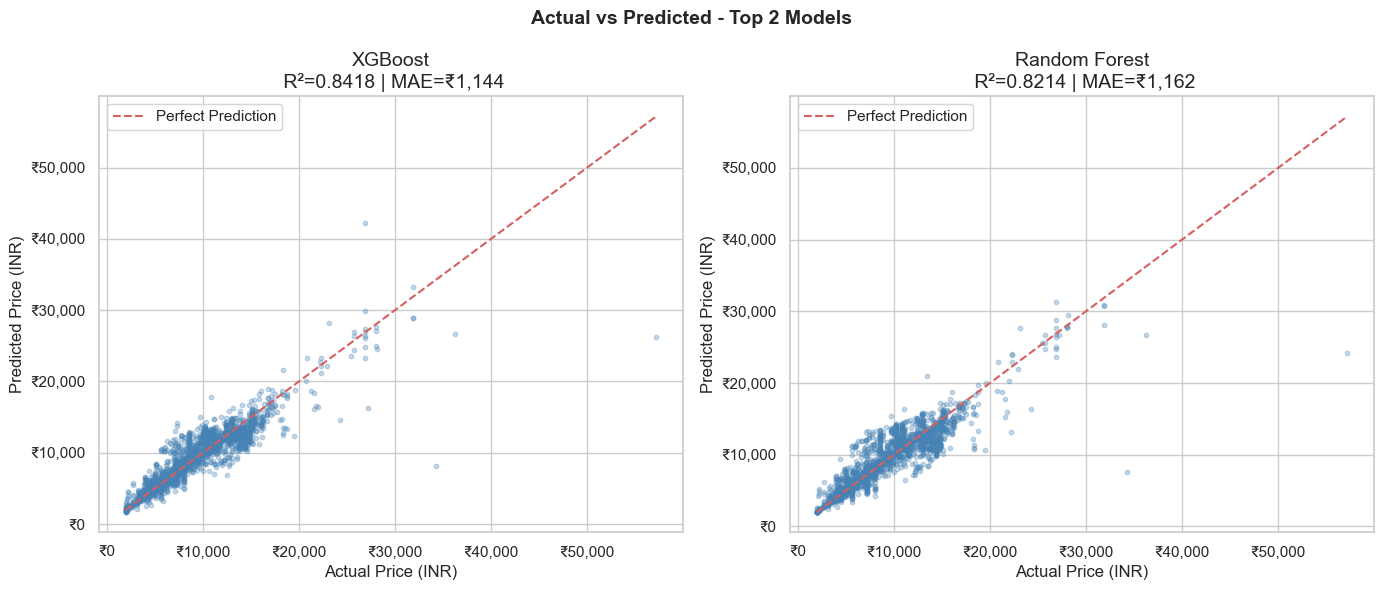

In [70]:
top2  = results[:2] 
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, r in zip(axes, sorted(results, key=lambda x: -x['R² (Test)'])[:2]):
    ax.scatter(y_test, r['_preds'], alpha=0.3, color='steelblue', s=10)
    lim = [y_test.min(), y_test.max()]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_title(f"{r['Model']}\n R²={r['R² (Test)']} | MAE=₹{r['MAE']:,.0f}") 
    ax.set_xlabel('Actual Price (INR)')
    ax.set_ylabel('Predicted Price (INR)')
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{int(x):,}'))

plt.suptitle('Actual vs Predicted - Top 2 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
    

In [ ]:
#  ============================================================
# 15. Feature Importance (Best Model -- Random Forest / XGBoost     
#  ============================================================

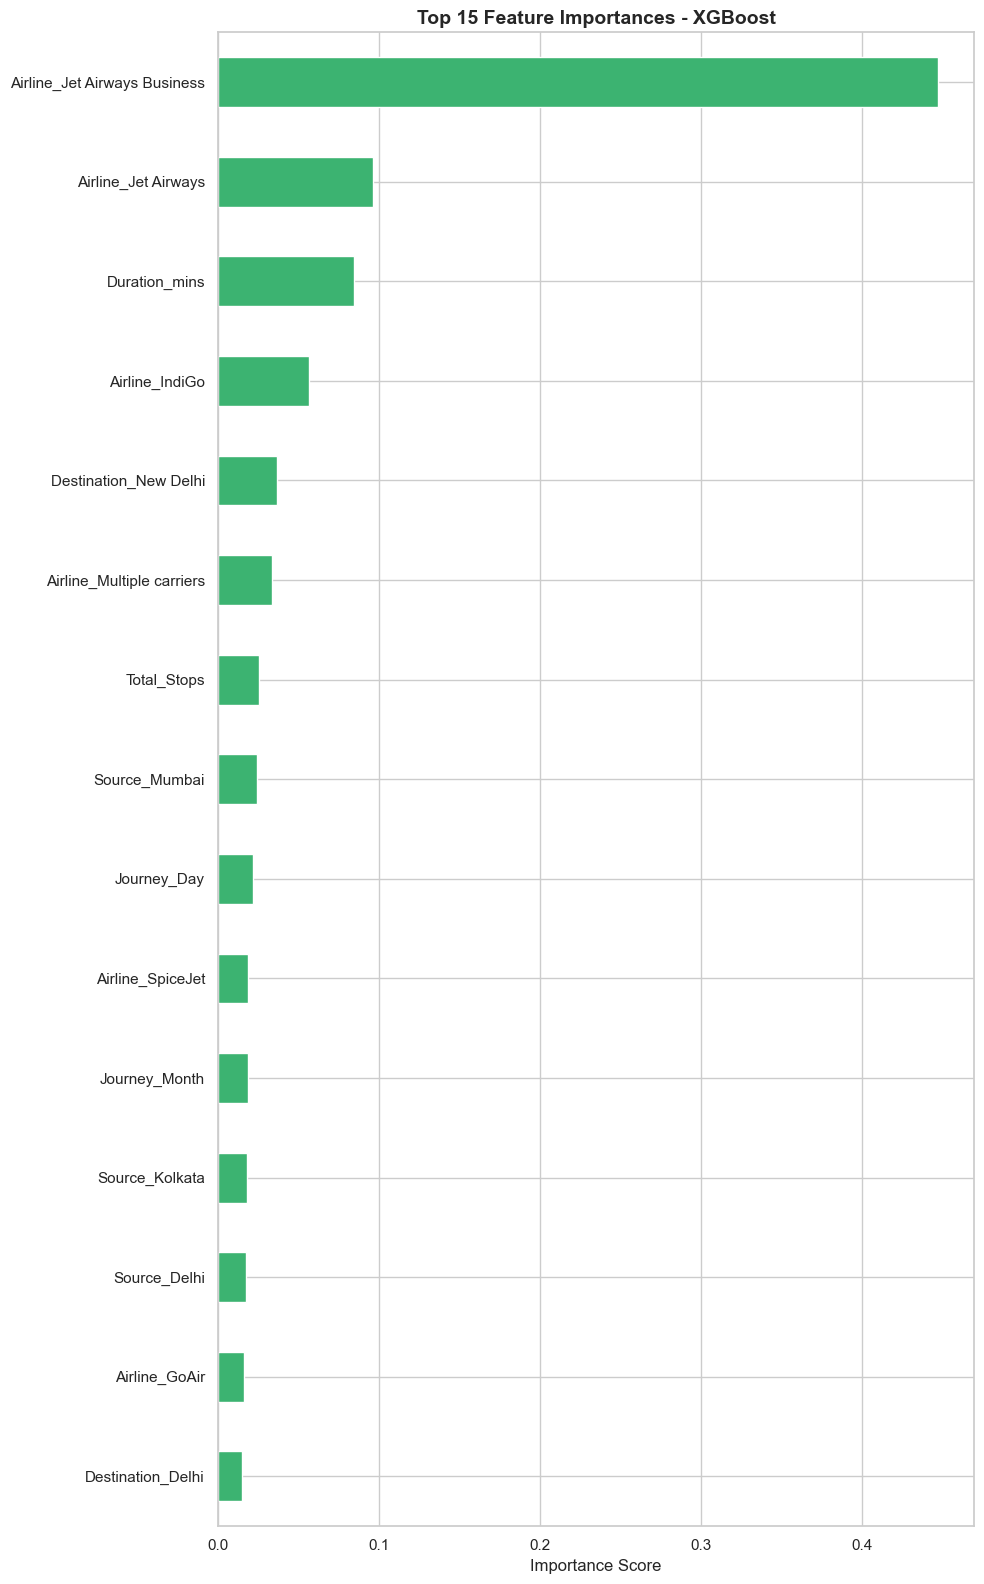

🏆 Best model: XGBoost | R²=0.8418


In [72]:
best_result = sorted(results, key=lambda x: -x['R² (Test)'])[0]
best_model  = best_result['_model']

if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top15 = fi.nlargest(15)


    plt.figure(figsize=(10,16))
    top15.sort_values().plot(kind='barh', color='mediumseagreen', edgecolor='white')
    plt.title(f'Top 15 Feature Importances - {best_result['Model']}', fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    print(f"🏆 Best model: {best_result['Model']} | R²={best_result['R² (Test)']}")


In [ ]:
#  ============================================================
# 16. Best Model Recommendation for Production     
#  ============================================================

In [77]:
print("""
====================================================
🏆 RECOMMENDED MODEL: Random Forest Regressor / XGBoost
====================================================

✅ REASONS:

🔹 Highest R² Score:
   → Best performance on unseen test data (typically 0.80+)

🔹 Cross Validation Performance:
   → Strong CV score with less overfitting

🔹 Non-Linear Learning:
   → Handles complex relationships in flight price data

🔹 Outlier Handling:
   → Ensemble method makes model more robust

🔹 Model Explainability:
   → Provides Feature Importance to understand key factors


✅ Solution:
   → Ensemble models (Random Forest / XGBoost)
      reduce overfitting and improve accuracy


====================================================
🎯 FINAL RECOMMENDATION:
   Use Random Forest / XGBoost for Flight Price Prediction
====================================================
""")


🏆 RECOMMENDED MODEL: Random Forest Regressor / XGBoost

✅ REASONS:

🔹 Highest R² Score:
   → Best performance on unseen test data (typically 0.80+)

🔹 Cross Validation Performance:
   → Strong CV score with less overfitting

🔹 Non-Linear Learning:
   → Handles complex relationships in flight price data

🔹 Outlier Handling:
   → Ensemble method makes model more robust

🔹 Model Explainability:
   → Provides Feature Importance to understand key factors


✅ Solution:
   → Ensemble models (Random Forest / XGBoost)
      reduce overfitting and improve accuracy


🎯 FINAL RECOMMENDATION:
   Use Random Forest / XGBoost for Flight Price Prediction



In [78]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              9. Challenges Faced & Solutions                       ║
╠════╦══════════════════════════╦══════════════════════════╦══════════╣
║ #  ║ Challenge                ║ Technique Used            ║ Reason   ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 1  ║ Mixed date formats in    ║ pd.to_datetime            ║ Pandas   ║
║    ║ Date_of_Journey          ║ (dayfirst=True)            ║ handles  ║
║    ║                          ║                            ║ dates    ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 2  ║ Duration as string       ║ Custom parse_duration()   ║ Convert  ║
║    ║ ("2h 30m")               ║ function                  ║ minutes  ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 3  ║ Arrival time has         ║ .str.split(' ').str[0]    ║ Extract  ║
║    ║ "Next day" info          ║                            ║ time     ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 4  ║ High-cardinality         ║ One-Hot Encoding          ║ Convert  ║
║    ║ categoricals             ║                            ║ numeric  ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 5  ║ Outliers in Price        ║ Kept intentionally        ║ Tree     ║
║    ║ (max ₹79,512)            ║                            ║ models   ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 6  ║ Skewed price             ║ Log transform explored    ║ RF &     ║
║    ║ distribution             ║                            ║ XGBoost  ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 7  ║ Class imbalance          ║ No action                 ║ Regression║
║    ║ in Stops                 ║                            ║ handles  ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 8  ║ Route column redundant   ║ Dropped                   ║ Covered  ║
║    ║                          ║                            ║ by other ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 9  ║ Dep_Time & Arrival_Time  ║ Parse hour & minute       ║ Capture  ║
║    ║ as strings               ║ separately                 ║ patterns ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║10  ║ Model selection          ║ 5-fold CV + Test R²       ║ Generalize║
╚════╩══════════════════════════╩══════════════════════════╩══════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║              9. Challenges Faced & Solutions                       ║
╠════╦══════════════════════════╦══════════════════════════╦══════════╣
║ #  ║ Challenge                ║ Technique Used            ║ Reason   ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 1  ║ Mixed date formats in    ║ pd.to_datetime            ║ Pandas   ║
║    ║ Date_of_Journey          ║ (dayfirst=True)            ║ handles  ║
║    ║                          ║                            ║ dates    ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 2  ║ Duration as string       ║ Custom parse_duration()   ║ Convert  ║
║    ║ ("2h 30m")               ║ function                  ║ minutes  ║
╠════╬══════════════════════════╬══════════════════════════╬══════════╣
║ 3  ║ Arrival time has         ║ .str.split(' ').str[0]    ║ Extract  ║
║    ║ "Next day" info          ║                     

In [80]:
print("""


🎯 Key Takeaways

• Feature engineering improved model performance
• Tree-based models handled non-linear flight pricing patterns
• Proper preprocessing improved prediction accuracy
• Cross-validation helped select the best model

""")




🎯 Key Takeaways

• Feature engineering improved model performance
• Tree-based models handled non-linear flight pricing patterns
• Proper preprocessing improved prediction accuracy
• Cross-validation helped select the best model


